In [4]:
import json, numpy as np
import pandas as pd

def fit_powerlaw(ns, var):
    """Var = A * 2^(-alpha*n). Trả về alpha, A, R^2, SE(alpha)."""
    ns = np.asarray(ns, float)
    y  = np.log2(np.asarray(var, float))
    slope, intercept = np.polyfit(ns, y, 1)
    alpha, A = -slope, 2**intercept
    yhat = intercept + slope*ns
    ss_res, ss_tot = np.sum((y-yhat)**2), np.sum((y-y.mean())**2)
    r2 = 1 - ss_res/ss_tot
    se = np.sqrt((ss_res/(len(ns)-2)) / np.sum((ns-ns.mean())**2))
    return alpha

d = json.load(open('gv_exact_all_eps1e-5.json'))
rows = []
for ini in d:
    for prob in d[ini]:
        for arch in d[ini][prob]:
            leaf = d[ini][prob][arch]
            ns  = sorted(int(x) for x in leaf)
            var = [np.var(leaf[str(n)], ddof=1) for n in ns]
            a = fit_powerlaw(ns, var)
            rows.append([ini, prob, arch, a])

df = pd.DataFrame(rows, columns=['init','problem','arch','alpha'])
print(df.round(3))

       init    problem      arch  alpha
0    normal      ising    single -0.327
1    normal      ising  circular -0.207
2    normal      ising      full  1.749
3    normal     maxcut    single  0.019
4    normal     maxcut  circular  0.169
5    normal     maxcut      full  1.962
6    normal  partition    single -0.595
7    normal  partition  circular -0.393
8    normal  partition      full  1.619
9       pi4      ising    single -0.328
10      pi4      ising  circular -0.128
11      pi4      ising      full -0.432
12      pi4     maxcut    single  0.007
13      pi4     maxcut  circular  0.288
14      pi4     maxcut      full -0.037
15      pi4  partition    single -0.584
16      pi4  partition  circular -0.321
17      pi4  partition      full -0.662
18  uniform      ising    single -0.127
19  uniform      ising  circular  0.064
20  uniform      ising      full  1.787
21  uniform     maxcut    single  0.119
22  uniform     maxcut  circular  0.367
23  uniform     maxcut      full  2.127


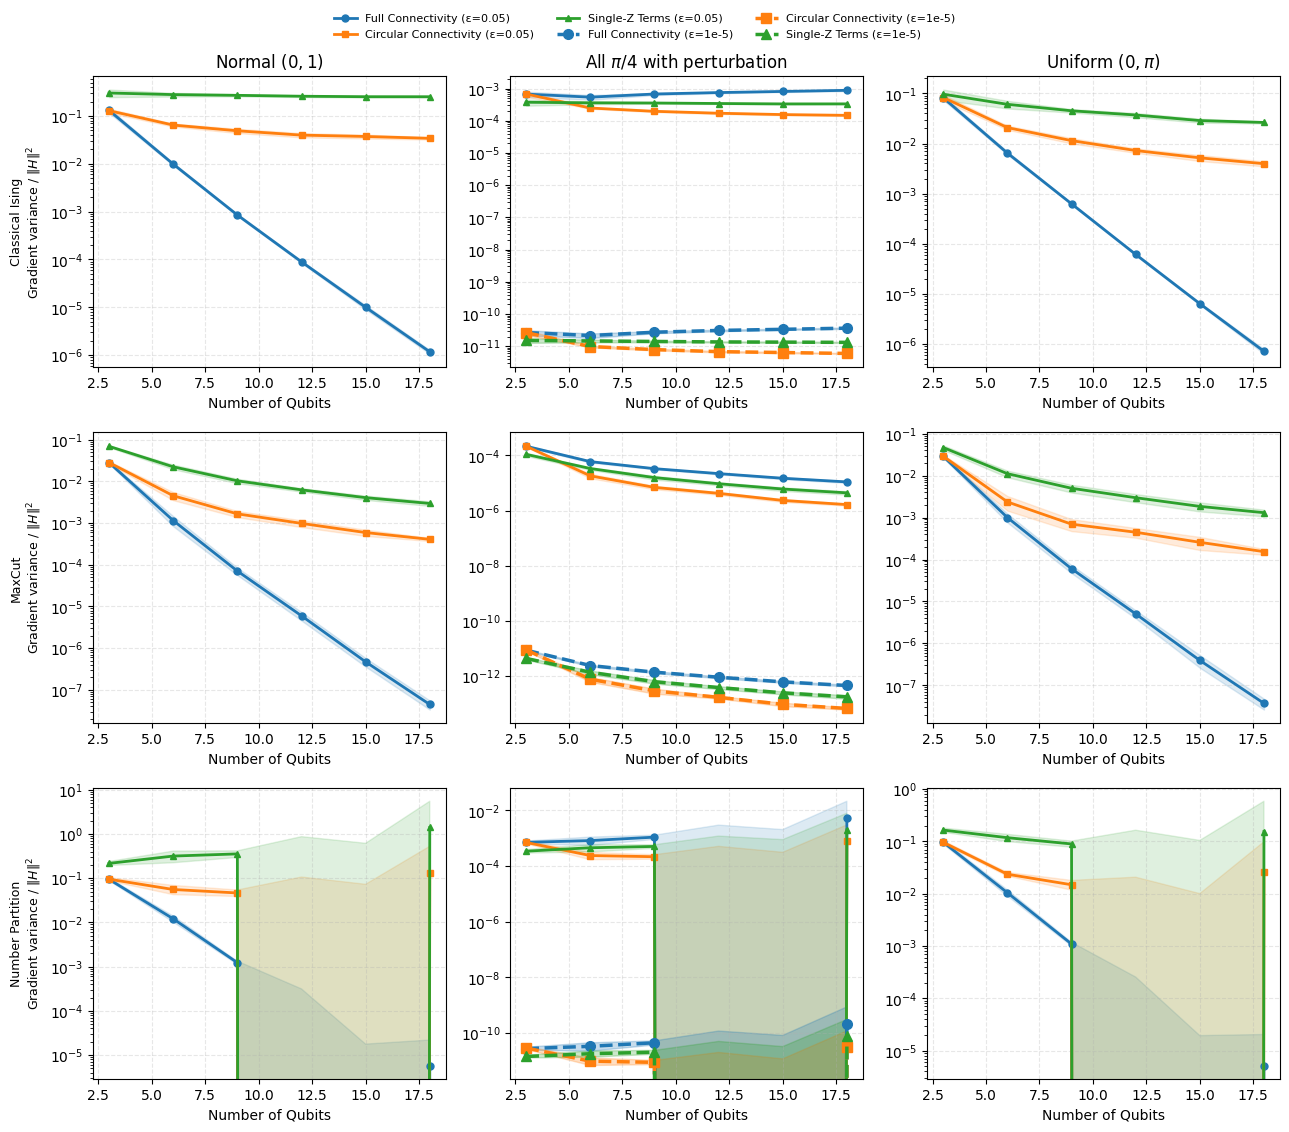

Saved: GV_compare_pi4_epsilon_scaled.pdf


In [6]:
import json
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Load gradient variance data
# ============================================================

with open("gv_exact_all_eps0.05.json", "r") as f:
    results_005 = json.load(f)

with open("gv_exact_all_eps1e-5.json", "r") as f:
    results_1e5 = json.load(f)

# ============================================================
# Load problem datasets (to compute Hamiltonian norms)
# ============================================================

with open("ising.json") as f:
    dataset_ising = {int(k): v for k, v in json.load(f).items()}

with open("maxcut.json") as f:
    dataset_maxcut = {int(k): v for k, v in json.load(f).items()}

with open("partition.json") as f:
    dataset_partition = {int(k): v for k, v in json.load(f).items()}

dataset = {
    'ising':     dataset_ising,
    'maxcut':    dataset_maxcut,
    'partition': dataset_partition,
}

# ============================================================
# Hamiltonian norm helpers (copied from IQP_circuit.py)
# — avoids iqpopt import dependency in this script
# ============================================================

def number_partition_obs(numbers):
    n = len(numbers)
    coeffs = []
    for i in range(n):
        for j in range(n):
            coeffs.append(numbers[i] * numbers[j])
    return np.array(coeffs)       # only coeffs needed for norm

def maxcut_obs_coeffs(n_qubits, edges, weights):
    coeffs = [sum(weights) / 2]
    for w in weights:
        coeffs.append(w / 2)      # |−w/2| → w/2, but we square anyway
    return np.array(coeffs)

def hamiltonian_norm_sq(mode_ham, n_qubits, problem_id):
    """
    ||H||^2 = sum_k c_k^2   (Frobenius / Hilbert-Schmidt proxy)

    This is the scale factor recommended by the supervisor:
    divide gradient variance by ||H||^2 so that comparisons across
    Hamiltonians reflect circuit structure, not Hamiltonian magnitude.
    """
    data = dataset[mode_ham][n_qubits][problem_id]

    if mode_ham == 'ising':
        coeffs = np.asarray(data)

    elif mode_ham == 'maxcut':
        edges, weights = data[0], data[1]
        edges = [tuple(e) for e in edges]
        coeffs = maxcut_obs_coeffs(n_qubits, edges, weights)

    elif mode_ham == 'partition':
        coeffs = number_partition_obs(data)

    return float(np.sum(coeffs ** 2))

# ============================================================
# Precompute norm lookup table
# norm_sq[mode_ham][n] = list of 10 norms (one per problem)
# ============================================================

qubits    = [3, 6, 9, 12, 15, 18]
n_problem = 10   # must match experiment

norm_sq = {}
for mode_ham in ['ising', 'maxcut', 'partition']:
    norm_sq[mode_ham] = {}
    for n in qubits:
        norm_sq[mode_ham][n] = [
            hamiltonian_norm_sq(mode_ham, n, pid)
            for pid in range(n_problem)
        ]

# ============================================================
# Helper: scale a list of per-problem variances by their norms
# ============================================================

def scaled_stats(raw_list, norms):
    """
    raw_list : list of 10 raw gradient variances (one per problem)
    norms    : list of 10 ||H||^2 values (same order)
    Returns  : (mean, std) of the 10 scaled values
    """
    scaled = np.array([v / nrm for v, nrm in zip(raw_list, norms)])
    return scaled.mean(), scaled.std()

# ============================================================
# Plot styles
# ============================================================

ham_names = {
    'ising':     'Classical Ising',
    'maxcut':    'MaxCut',
    'partition': 'Number Partition',
}

circuit_colors  = {'full': '#1f77b4', 'circular': '#ff7f0e', 'single': '#2ca02c'}
circuit_markers = {'full': 'o',       'circular': 's',       'single': '^'}
circuit_labels  = {
    'full':     'Full Connectivity',
    'circular': 'Circular Connectivity',
    'single':   'Single-Z Terms',
}

init_cols  = ['normal', 'pi4', 'uniform']
col_titles = {
    'normal':  r'Normal $(0, 1)$',
    'pi4':     r'All $\pi/4$ with perturbation',
    'uniform': r'Uniform $(0, \pi)$',
}

# ============================================================
# Plot
# ============================================================

fig, axes = plt.subplots(3, 3, figsize=(13, 11))

for row, mode_ham in enumerate(['ising', 'maxcut', 'partition']):
    for col, init_name in enumerate(init_cols):
        ax = axes[row][col]
        norms = norm_sq[mode_ham]   # dict n -> list[10]

        # --- ε = 0.05 (solid lines) ---
        res = results_005[init_name][mode_ham]
        for mode_circuit in ['full', 'circular', 'single']:
            means, stds = zip(*[
                scaled_stats(res[mode_circuit][str(n)], norms[n])
                for n in qubits
            ])
            means = np.array(means)
            stds  = np.array(stds)
            color  = circuit_colors[mode_circuit]
            marker = circuit_markers[mode_circuit]
            ax.plot(qubits, means, marker + '-', color=color,
                    label=f'{circuit_labels[mode_circuit]} (ε=0.05)',
                    linewidth=2, markersize=5)
            ax.fill_between(qubits, means - stds, means + stds,
                            color=color, alpha=0.15)

        # --- ε = 1e-5 (dashed lines, pi4 only) ---
        if init_name == 'pi4':
            res2 = results_1e5[init_name][mode_ham]
            for mode_circuit in ['full', 'circular', 'single']:
                means2, stds2 = zip(*[
                    scaled_stats(res2[mode_circuit][str(n)], norms[n])
                    for n in qubits
                ])
                means2 = np.array(means2)
                stds2  = np.array(stds2)
                color  = circuit_colors[mode_circuit]
                marker = circuit_markers[mode_circuit]
                ax.plot(qubits, means2, marker + '--', color=color,
                        label=f'{circuit_labels[mode_circuit]} (ε=1e-5)',
                        linewidth=2.5, markersize=7, alpha=1.0)
                ax.fill_between(qubits, means2 - stds2, means2 + stds2,
                                color=color, alpha=0.25)

        ax.set_yscale('log')
        ax.grid(True, alpha=0.3, linestyle='--')
        ax.set_xlabel('Number of Qubits')

        if col == 0:
            ax.set_ylabel(
                f'{ham_names[mode_ham]}\n'
                r'Gradient variance / $\|H\|^2$',
                fontsize=9
            )
        if row == 0:
            ax.set_title(col_titles[init_name])

# Legend from the pi4 top panel (has both ε values)
handles, labels_ = axes[0][1].get_legend_handles_labels()
fig.legend(handles, labels_, loc='upper center', ncol=3,
           bbox_to_anchor=(0.5, 1.03), frameon=False, fontsize=8)

plt.tight_layout()
#plt.savefig("GV_compare_pi4_epsilon_scaled.pdf", dpi=300, bbox_inches='tight')
plt.show()
print("Saved: GV_compare_pi4_epsilon_scaled.pdf")